# R&D-8. Сравнение методов множественного тестирования (OR-регион)

Тонкая витрина над пакетом `rnd_reports.multiple_testing`. Таблица контракта `id, treatment, target_1..n`: каждая target-метрика — гипотеза о treatment effect, всё семейство обслуживает один **OR-claim** («есть ли хотя бы один надёжный сигнал и какие именно метрики его дали»).

Сравниваем методы OR-региона: **Bonferroni, Holm, Westfall–Young (maxT), Romano–Wolf (stepdown)** — контроль FWER; **Benjamini–Hochberg** — единственный FDR-ориентир. Логика — на готовых решениях scipy/statsmodels (своё — только Romano–Wolf stepdown). Контекст и выводы — в [`report.md`](report.md).

Два уровня сравнения: (1) **single-table** — adjusted p-value и решения методов на одной таблице (работает и на своей реальной); (2) **operating characteristics** (Monte-Carlo) — эмпирический FWER и power по методам в зависимости от корреляции метрик `rho` (там Westfall–Young / Romano–Wolf выигрывают).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from rnd_reports.multiple_testing import (
    make_ab_table, run_comparison, operating_characteristics, rho_grid, METHOD_NAMES, plot_pvalue_comparison,
)

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40); pd.set_option('display.precision', 4)
FIG = Path('results/08_multiple_testing/figures'); FIG.mkdir(parents=True, exist_ok=True)
ALPHA = 0.05; SEED = 42

## 1. Данные: синтетика или своя таблица

По умолчанию — синтетика с известной правдой и коррелированными метриками (`rho` — ключ к различию методов). Чтобы прогнать на своих данных, раскомментируй помеченный блок: контракт колонок `id, treatment, target_*`, а `true_effects = None` отключает оценку power/FDR (на реальных данных правда неизвестна).

In [2]:
df, true_effects = make_ab_table(n=4000, n_targets=15, rho=0.5, n_true=3, effect=0.11, seed=SEED)

# --- ПОДМЕНА синтетики на свою таблицу (раскомментировать) ----------------------
# df = pd.read_csv('data/08_multiple_testing/my_table.csv')  # контракт: id, treatment, target_*
# true_effects = None   # реальные данные: правда неизвестна -> блок power/FDR пропускается
# --------------------------------------------------------------------------------

print(f'таблица: {df.shape[0]} юнитов, {df.shape[1] - 2} target-метрик')
print('истинно ненулевые эффекты:', {k: v for k, v in (true_effects or {}).items() if v})

таблица: 4000 юнитов, 15 target-метрик
истинно ненулевые эффекты: {'target_1': 0.11, 'target_2': 0.11, 'target_3': 0.11}


## 2. Single-table: решения методов на одной таблице

`run_comparison` считает элементарные Welch-тесты по каждой метрике и adjusted p-value всех методов. Эта вьюшка одинаково работает на синтетике и на своей реальной таблице; при известной правде добавляется оценка TP/FP/FDR/power.

Кроме reject-решений сравниваем методы **«через p-values»** скалярными сводками (`res.pvalue_profile`): средний adjusted-p на истинно-ненулевых метриках (`mean_p_adj_signal` — сила детекции), на нулевых (`mean_p_adj_null` — калибровка) и `conservativeness_gap` = среднее `p_adj − p_raw` (инфляция над raw, считается и на реальных данных). Значения **FWER-методов** сравнимы между собой напрямую; Benjamini–Hochberg — это q-value «другой валюты» ошибки (FDR), поэтому его строку читаем отдельно, а не в одном ряду с FWER.

In [3]:
res = run_comparison(df, true_effects=true_effects, alpha=ALPHA, n_resamples=1000, random_state=SEED)

print('=== Сравнительная таблица: adjusted p-value по методам (топ по силе сигнала) ===')
show = ['target', 'effect', 'p_value'] + [f'p_adj_{m}' for m in METHOD_NAMES]
display(res.table[show].head(8))

print('\n=== Сколько target-метрик отвергнул каждый метод ===')
display(res.method_summary)

if res.truth_evaluation is not None:
    print('\n=== Оценка против известной правды (только синтетика) ===')
    display(res.truth_evaluation)

print('\n=== Скалярные сводки «через p-values»: детекция / калибровка / консервативность ===')
display(res.pvalue_profile)

=== Сравнительная таблица: adjusted p-value по методам (топ по силе сигнала) ===

=== Сколько target-метрик отвергнул каждый метод ===

=== Оценка против известной правды (только синтетика) ===

=== Скалярные сводки «через p-values»: детекция / калибровка / консервативность ===


,target,effect,p_value,p_adj_bonferroni,p_adj_holm,p_adj_westfall_young,p_adj_romano_wolf,p_adj_benjamini_hochberg
0,target_3,0.1539,2.7379e-07,4.1068e-06,4.1068e-06,0.001,0.001,4.1068e-06
1,target_2,0.1344,7.8060e-06,1.1709e-04,1.0928e-04,0.001,0.001,5.2493e-05
2,target_1,0.1243,1.0499e-05,1.5748e-04,1.3648e-04,0.001,0.001,5.2493e-05
3,target_13,0.0249,4.8875e-01,1.0000e+00,1.0000e+00,0.999,0.997,9.6831e-01
4,target_12,0.0232,5.1921e-01,1.0000e+00,1.0000e+00,1.000,0.997,9.6831e-01
5,target_14,-0.0218,5.6038e-01,1.0000e+00,1.0000e+00,1.000,0.998,9.6831e-01
6,target_11,-0.0186,5.9844e-01,1.0000e+00,1.0000e+00,1.000,0.998,9.6831e-01
7,target_9,0.0161,6.3621e-01,1.0000e+00,1.0000e+00,1.000,0.998,9.6831e-01


,method,error_control,n_rejected
0,bonferroni,FWER,3
1,holm,FWER,3
2,westfall_young,FWER,3
3,romano_wolf,FWER,3
4,benjamini_hochberg,FDR,3


,method,error_control,true_positives,false_positives,realized_fdr,power,fwer_event
0,bonferroni,FWER,3,0,0.0,1.0,False
1,holm,FWER,3,0,0.0,1.0,False
2,westfall_young,FWER,3,0,0.0,1.0,False
3,romano_wolf,FWER,3,0,0.0,1.0,False
4,benjamini_hochberg,FDR,3,0,0.0,1.0,False


,method,error_control,mean_p_adj_signal,mean_p_adj_null,conservativeness_gap
0,bonferroni,FWER,9.2892e-05,1.0000,0.2321
1,holm,FWER,8.3291e-05,1.0000,0.2321
2,westfall_young,FWER,9.9900e-04,0.9999,0.2323
3,romano_wolf,FWER,9.9900e-04,0.9983,0.2309
4,benjamini_hochberg,FDR,3.6364e-05,0.9702,0.2083


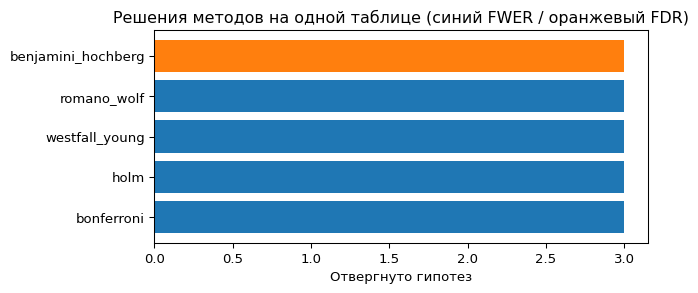

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
s = res.method_summary.sort_values('n_rejected')
colors = ['#1f77b4' if e == 'FWER' else '#ff7f0e' for e in s['error_control']]
ax.barh(s['method'], s['n_rejected'], color=colors)
ax.set_xlabel('Отвергнуто гипотез'); ax.set_title('Решения методов на одной таблице (синий FWER / оранжевый FDR)')
fig.tight_layout(); fig.savefig(FIG / 'single_table_rejections.png', dpi=95); plt.show()

### Визуализация: эффекты с ДИ и p-value по методам

Левая панель — эффект каждой метрики с доверительным интервалом (точки красные, если метрика отвергнута Holm); правая — raw и adjusted p-value по всем методам в лог-шкале с порогом α. Видно, как FWER-коррекция отодвигает p-value к незначимости.

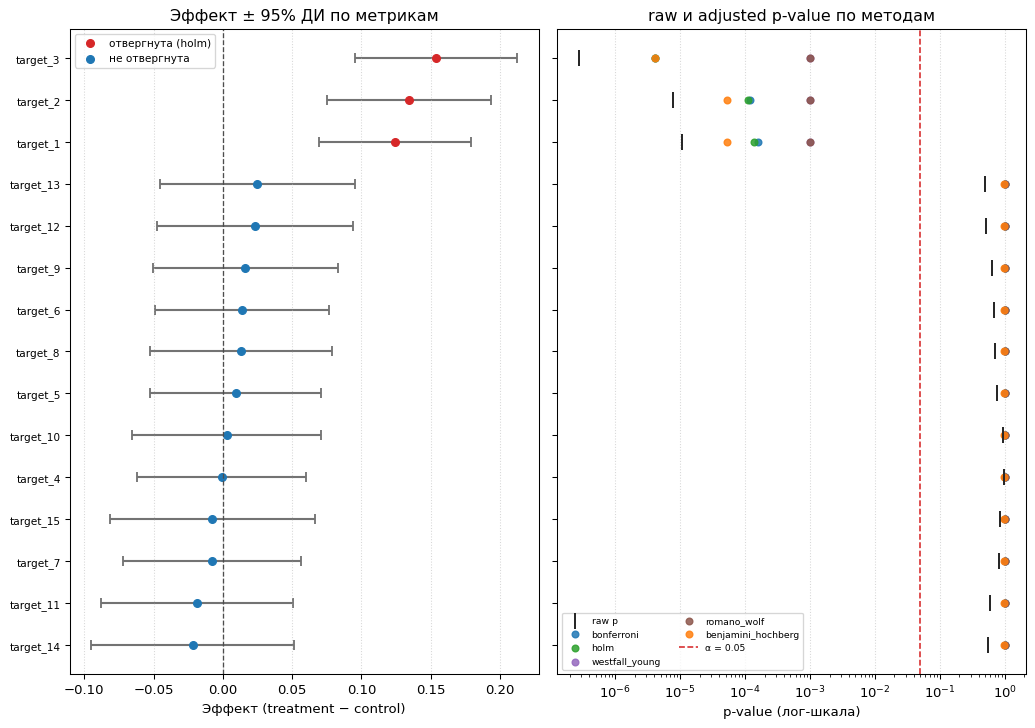

In [5]:
fig = plot_pvalue_comparison(res, alpha=ALPHA)
fig.savefig(FIG / 'pvalue_ci_comparison.png', dpi=95, bbox_inches='tight')
plt.show()

## 3. Operating characteristics (Monte-Carlo, только синтетика)

Одна таблица не позволяет сравнить методы — усредняем по многим симуляциям с известной правдой. Для сетки корреляций `rho` считаем по каждому методу **эмпирический FWER** (доля симуляций с ≥1 ложным отвержением) и **average power** (доля найденных истинных эффектов). Ожидание: все FWER-методы держат FWER ≤ α, но Westfall–Young / Romano–Wolf наращивают power с ростом корреляции, а Bonferroni/Holm — нет.

In [6]:
scenarios = rho_grid([0.0, 0.3, 0.6, 0.9], n=2500, n_targets=20, n_true=4, effect=0.11)
oc = operating_characteristics(scenarios, n_sims=80, alpha=ALPHA, n_resamples=300, base_seed=1)

print('=== Power по методам и корреляции метрик rho ===')
display(oc.pivot(index='method', columns='rho', values='power').round(3))
print('\n=== Эмпирический FWER по методам и rho (цель FWER-методов: <= alpha=0.05) ===')
display(oc.pivot(index='method', columns='rho', values='fwer').round(3))

=== Power по методам и корреляции метрик rho ===

=== Эмпирический FWER по методам и rho (цель FWER-методов: <= alpha=0.05) ===


rho,0.0,0.3,0.6,0.9
method,,,,
benjamini_hochberg,0.597,0.638,0.641,0.578
bonferroni,0.481,0.503,0.519,0.422
holm,0.497,0.519,0.531,0.431
romano_wolf,0.491,0.534,0.591,0.666
westfall_young,0.475,0.519,0.581,0.659


rho,0.0,0.3,0.6,0.9
method,,,,
benjamini_hochberg,0.138,0.075,0.050,0.025
bonferroni,0.050,0.012,0.025,0.000
holm,0.062,0.012,0.025,0.000
romano_wolf,0.062,0.012,0.062,0.050
westfall_young,0.062,0.012,0.062,0.050


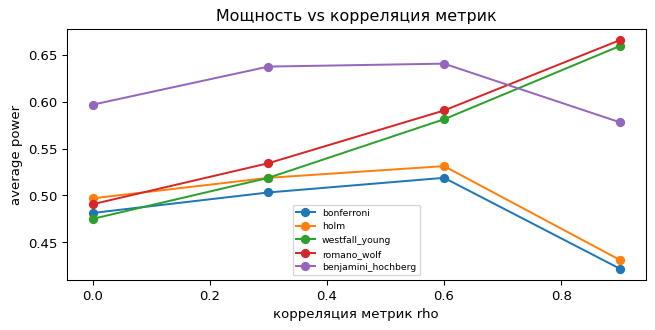

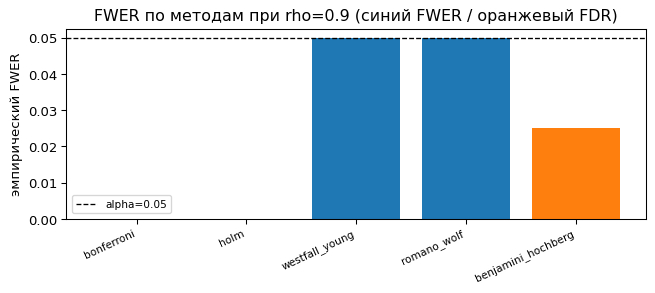

In [7]:
piv_pow = oc.pivot(index='rho', columns='method', values='power')
fig, ax = plt.subplots(figsize=(7, 3.6))
for m in METHOD_NAMES:
    ax.plot(piv_pow.index, piv_pow[m], marker='o', label=m)
ax.set_xlabel('корреляция метрик rho'); ax.set_ylabel('average power'); ax.set_title('Мощность vs корреляция метрик')
ax.legend(fontsize=7); fig.tight_layout(); fig.savefig(FIG / 'power_vs_rho.png', dpi=95); plt.show()

rho_hi = oc['rho'].max()
hi = oc[oc['rho'] == rho_hi].set_index('method').loc[METHOD_NAMES]
colors = ['#1f77b4' if e == 'FWER' else '#ff7f0e' for e in hi['error_control']]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(hi)), hi['fwer'], color=colors)
ax.axhline(ALPHA, color='k', ls='--', lw=1, label=f'alpha={ALPHA}')
ax.set_xticks(range(len(hi))); ax.set_xticklabels(hi.index, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('эмпирический FWER'); ax.set_title(f'FWER по методам при rho={rho_hi:g} (синий FWER / оранжевый FDR)')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / 'fwer_by_method.png', dpi=95); plt.show()

## 4. Выводы

- На single-table все методы дают согласованные решения по сильным сигналам; различие — на грани значимости, где Romano–Wolf и Westfall–Young менее консервативны при том же контроле FWER.
- На operating characteristics видно главное: при росте корреляции метрик `rho` power Westfall–Young / Romano–Wolf растёт (они используют совместное распределение статистик), тогда как Bonferroni/Holm её игнорируют и остаются плоскими; FWER всех четырёх FWER-методов держится у α.
- Benjamini–Hochberg (FDR) мощнее, но допускает больше ложных находок — это компаратор для exploration, а не launch-процедура OR-claim.
- Практика: для коррелированного OR-семейства — Romano–Wolf / Westfall–Young; для малого простого семейства — Holm/Bonferroni. Декомпозиция бизнес-вклада (effect sizes, CI, OEC) — отдельная задача, см. `report.md`.